# Classification

In [1]:
# Importing packages!
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

You can learn more about classification and machine learning on [scikit learn](https://scikit-learn.org/stable/machine_learning_map.html).

## What is Machine Learning?

Machine learning consists of algorithms that can "learn" patterns in data it's trained on, then make **inferences** about new data. Machine learning includes areas like regression, dimensionality reduction, clustering, and classification. It is a subset of the broad field of artificial intelligence.

## Introduction to Classification and K-nearest Neighbors

One type of machine learning is classification. Oftentimes, specific groups of data may share similar quantitative characteristics. Classification utilizes these similarities to classify an unlabeled observation in a group based on how its characteristics compare to other observations. 

For example, if you have various species groups, you can expect the weight and height of the members of the same species to be somewhat similar to each other, compared to that of a drastically different species. If you are given a unclassified organism with the weight and height similar to a certain group, then a classifier would label that organism as the group it's most similar to.

K-nearest neighbors is a type of classifier algorithm. The algorithm works by looking at the nearest **neighbors** of the unclassified observation, then classifying it based off of the classification of those neighbors. The closest neighbors are determined by calculating the **distance** from the observation to other observations, based on each observations' combined characteristics. A common distance measure is **Euclidean distance**, which measures a straight line between the current observation and the other observations. The number of neighbors is referred to as *k*, and can be defined while developing the classifier.

![text](knn.png)

## Performing K-nearest Neighbors Classification

We'll be creating a classifier using the breast cancer dataset. This dataset contains various measures of different cells, such as clump thickness, uniformity of cell shape, bland chromatin, and more, as well as the classification of the cell as a cancerous or non-cancerous cell.

In [2]:
# Reads in breast cancer dataset
cancer_df = pd.read_csv('breastcancer_rv.csv')
# Views the data
cancer_df.head()

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,5,1,1,1,2,1,3,1,1,no_cancer
1,5,4,4,5,7,10,3,2,1,no_cancer
2,3,1,1,1,2,2,3,1,1,no_cancer
3,6,8,8,1,3,4,3,7,1,no_cancer
4,4,1,1,3,2,1,3,1,1,no_cancer


Before creating the classifier, let's visualize the data to see if the cancerous and non-cancerous cells divide into distinct groups.

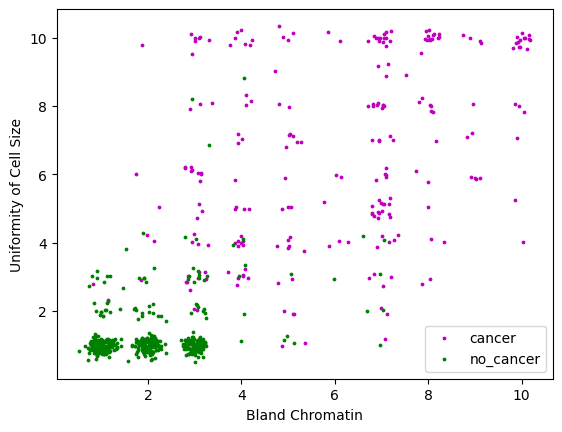

In [13]:
# Creates a figure for plotting
fig, ax1 = plt.subplots()

# Creates a random jitter because many points have the same values
def make_random(a):
    return a + np.random.normal(0, 0.15, len(a))

# Sets outcomes and data columns
outcomes = ['cancer', 'no_cancer']
xcol = 'Bland Chromatin'
ycol = 'Uniformity of Cell Size'

# Sets plotting colors
colors=['m','g']

# Plots cancerous and non-cancerous cells separately
for index, outcome in enumerate(outcomes):

    # Gets the data indices for the class
    truth_indices = cancer_df['Class'] == outcome
    # Scatters the class points with a jitter
    ax1.scatter(make_random(cancer_df.loc[truth_indices, xcol]), make_random(cancer_df.loc[truth_indices, ycol]), 3, color = colors[index], label = outcome)

# Labels plot
ax1.set_xlabel(xcol)
ax1.set_ylabel(ycol)
ax1.legend()

The two types of cells clearly divide into groups based on the plotted characteristics, so this dataset would be suitable for developing a classifier.

The first part of the k-nearest neighbors classification algorithm is to calculate the distance between our data points. We'll define the function `distance()` to calculate the Euclidean distance between two points. The inputs for this function are two rows in our DataFrame.

In [ ]:
def distance(row1, row2):
    # Removes the class column
    row1 = row1.drop('Class')
    row2 = row2.drop('Class')
    
    # Calculates the Euclidean distance
    dist = np.sqrt(np.sum((row1 - row2) ** 2))

    # Returns the distance
    return dist

Let's test the function on two cell observations.

In [5]:
test_distance = distance(cancer_df.loc[0], cancer_df.loc[1])
print(f'The Euclidean distance between these two points is {test_distance}.')

The Euclidean distance between these two points is 11.874342087037917.


For classifying, we want to know the observation's distance to all other points. We can create the function `calc_distance_to_all_points()` to calculate these distances. This function takes in the DataFrame and a row as an input and returns the distances. It can utilize our `distance()` function from earlier.

In [28]:
def calc_distance_to_all_points(df, testrow):
    # Creates a list for distances
    distances = []
    # Extracts the number of rows
    num_rows = df.shape[0]

    # Iterates through all the rows
    for row in range(num_rows):
        # Extracts row
        cur_row = df.iloc[row, :]
        # Calculates distance
        cur_distance = distance(cur_row, testrow)
        # Adds to distances list
        distances.append(cur_distance)

    # Returns list of distances
    return distances

Let's call this function on the first observation and print the first few distances.

In [ ]:
test_distances = calc_distance_to_all_points(cancer_df, cancer_df.loc[0])
print(f'The first four distances are {test_distances[:4]}.')

The first four distances are [np.float64(0.0), np.float64(11.874342087037917), np.float64(2.23606797749979), np.float64(12.041594578792296)].


Once all the distances are calculated, the k-nearest neighbors need to be found. This is done by sorting all the distances to find the closest neighbors. The function `find_k_closest()` does this. It takes the DataFrame, a row, and a number of k neighbors as an input, then finds the k closest neighbors and returns their row indices. There is also an argument for dropping the closest point.

In [11]:
def find_k_closest(df, testrow, k, drop_closest=True):
    # Calculates distances
    distances = calc_distance_to_all_points(df, testrow)
    # Sorts indices
    sorted_indices = np.argsort(distances)

    # Returns indices, either including or excluding closest neighbor
    if drop_closest:
        return sorted_indices[1:k+1]
    else:
        return sorted_indices[1:k]

Let's extract the 5 closest neighbors for a random observation.

In [19]:
closest_inds = find_k_closest(cancer_df, cancer_df.loc[121], 5)
print(f'The closest indices are {closest_inds}')

The closest indices are [ 56 147 303 142 173]


Let's plot these indices.

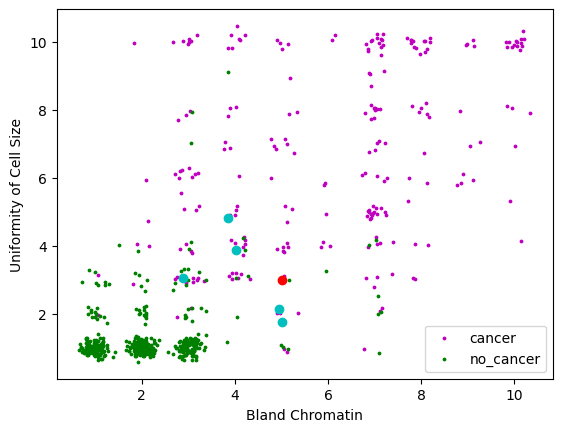

In [21]:
# Creates figure for plotting
fig, ax2 = plt.subplots()

# Sets outcomes and data columns
outcomes = ['cancer', 'no_cancer']
xcol = 'Bland Chromatin'
ycol = 'Uniformity of Cell Size'

# Sets plotting colors
colors = ['m', 'g']

# Plots cancerous and non-cancerous cells
for index, outcome in enumerate(outcomes):
    # Extracts the cell indices
    truth_indices = cancer_df['Class'] == outcome
    # Scatters the cells
    ax2.scatter(make_random(cancer_df.loc[truth_indices, xcol]), make_random(cancer_df.loc[truth_indices, ycol]), 3, color = colors[index], label = outcome)

# Labels the plot
ax2.set_xlabel(xcol)
ax2.set_ylabel(ycol)
ax2.legend()

# Plots the individual observation
ax2.plot(cancer_df.loc[121, xcol], cancer_df.loc[121, ycol], 'ro')
# Plots the k-nearest neighbors
ax2.scatter(make_random(cancer_df.loc[closest_inds, xcol]), make_random(cancer_df.loc[closest_inds, ycol]), color = 'c')

To finally classify the point that we've gathered the k-nearest neighbors for, we can tally the classifications for the neighboring points, then determine which category our observation is likely is. We can create the function `classify()` to do this, which performs the entire k-nearest neighbors classification. It takes a DataFrame, an observation row, the number of k neighbors, and a boolean value for dropping the closest neighbor, then returns the classification of the point.

In [22]:
def classify(df, testrow, k, drop_closest=True):
    # Finds the closest neighbors
    closest_inds = find_k_closest(df, testrow, k, drop_closest)
    
    # Sums the number of cancerous cell neighbors
    cancer_ct=sum(df['Class'].iloc[closest_inds] == 'cancer')
    # Sums the number of non-cancerous cell neighbors
    nocancer_ct=sum(df['Class'].iloc[closest_inds] == 'no_cancer')

    # Returns the classification
    if cancer_ct >= nocancer_ct:
        return 'cancer'
    else:
        return 'no_cancer'

Let's classify the point that we plotted above by classifying it using its 15 nearest neighbors.

In [24]:
classification = classify(cancer_df, cancer_df.iloc[121,:], 15)
print(f'The cell classification is {classification}.')

The cell classification is cancer.


To test the performance of our classifier, we can divide our dataset into test and training sets, then use them to evaluate the accuracy of the classifier. We can create the function `evaluate_accuracy()` to do so, which takes the test set, training set, and a value of k as inputs, then returns the accuracy.

In [25]:
# Gets the number of rows
num_rows = cancer_df.shape[0]

# Permutes the indices to randomize the sets
permuted_indices = np.random.permutation(np.arange(num_rows))

# Makes 80% of the data training data
frac_training = 0.8

# Gets the training and test set indices
training_ind = permuted_indices[0:int(0.8 * num_rows)]
test_ind = permuted_indices[int(0.8 * num_rows):]

# Subsets the training and test data
training_df = cancer_df.iloc[training_ind, :]
test_df = cancer_df.iloc[test_ind,:]

In [26]:
def evaluate_accuracy(training_df, test_df, k):
    # Extracts the number of test rows
    num_test_rows = test_df.shape[0]
    # Creates a counter for the number of correct classifications
    correct_total = 0
    
    # Iterates through test data
    for rowind in range(num_test_rows):
        # Extracts test row
        test_row = cancer_df.iloc[rowind,:]
        
        # Predicts classification
        predicted_outcome = classify(training_df, test_row, k, drop_closest=False)

        # Checks if classification is correct
        if predicted_outcome == test_row['Class']:
            correct_total = correct_total + 1

    # Returns accuracy
    return correct_total/num_test_rows

Let's test the accuracy of our classifier using a k of 3.

In [27]:
acc_k3 = evaluate_accuracy(training_df, test_df, 3)
print(f'The accuracy is {acc_k3}.')

The accuracy is 0.948905109489051.
